# Visão geral do problema, dados e análise exploratória

## Contexto do projeto

Este notebook reúne a apresentação do problema, a inspeção inicial dos dados e a análise exploratória da base **Breast Cancer Wisconsin (Diagnostic)**.

- **Arquivo:** `src/db/models/breast-cancer-wisconsin-data/data.csv`
- **Fonte:** [Kaggle — UCI ML](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data)
- **Alvo:** coluna `diagnosis` — **M** = maligno, **B** = benigno
- **Tipo de problema:** classificação binária para apoio à triagem
- **Uso pretendido:** apoio à decisão clínica; o médico tem a palavra final
- **Risco crítico:** falso negativo, quando um tumor maligno é previsto como benigno
- **Figuras:** `src/db/outputs/breast-cancer-wisconsin-data/02-analise-exploratoria/figures/`

## População representada

Cada linha descreve uma **amostra de massa mamária** com medidas numéricas do núcleo celular — como raio, textura, perímetro, área e simetria — extraídas de imagens digitalizadas de aspirado por agulha fina (FNA).

## Objetivo desta etapa

Compreender a estrutura, a qualidade, a distribuição e as relações entre os atributos antes do pré-processamento e do treinamento. Este notebook não exporta artefatos utilizados diretamente pela etapa de modelagem.

## 1 - Carregando os dados

In [1]:
# 1 - Responsável por mapear a pasta base do projeto e fonte de dados:
# Aqui basicamente mapeio as pastas base:

from pathlib import Path
import sys, os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Encontra a raiz do repositório (notebooks em subpastas ou na raiz)
def encontrar_raiz() -> Path:
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "src" / "db").is_dir():
            return candidato
    raise FileNotFoundError("Raiz do repositório não encontrada.")

RAIZ = encontrar_raiz()
OUTPUT_BASE = RAIZ / "src/db/outputs/breast-cancer-wisconsin-data"

CAMINHO_CSV = RAIZ / "src/db/models/breast-cancer-wisconsin-data/data.csv"
PASTA_BASE = OUTPUT_BASE / "02-analise-exploratoria"
PASTA_FIGURAS = PASTA_BASE / "figures"
PASTA_METRICAS = PASTA_BASE / "metrics"
PASTA_ARTEFATOS = PASTA_BASE / "artifacts"

for pasta in (PASTA_FIGURAS, PASTA_METRICAS, PASTA_ARTEFATOS):
    pasta.mkdir(parents=True, exist_ok=True)

In [2]:
# 2 - Responsável por carregar os dados para analise:

dados_extraidos = pd.read_csv(CAMINHO_CSV)
dados_extraidos.columns = dados_extraidos.columns.str.strip()  # cabeçalho do CSV pode ter espaços extras

sns.set_theme(style="whitegrid")

print(f"Arquivo carregado: {CAMINHO_CSV}")
print("Dimensão (linhas, colunas):", dados_extraidos.shape)

dados = dados_extraidos.drop(
    columns=["id", "Unnamed: 32"],
    errors="ignore"
)

Arquivo carregado: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\models\breast-cancer-wisconsin-data\data.csv
Dimensão (linhas, colunas): (569, 33)


## 2 - Estatísticas descritivas e qualidade dos dados

Verificamos ausentes, duplicatas, resumo numérico e a média dos primeiros atributos em cada diagnóstico.

In [3]:
# Apresentação de quantidade de resultados Benigno e Maligno -> Em fromato de tabela;

COLUNA_ALVO = "diagnosis"
tabela_diagnostico = (
    dados[COLUNA_ALVO]
    .value_counts()
    .rename_axis("Diagnóstico")
    .reset_index(name="Quantidade")
)

tabela_diagnostico["Percentual"] = (
    tabela_diagnostico["Quantidade"]
    .div(tabela_diagnostico["Quantidade"].sum())
    .mul(100)
    .round(1)
)

tabela_diagnostico["Diagnóstico"] = tabela_diagnostico["Diagnóstico"].map({
    "M": "Maligno",
    "B": "Benigno"
})

display(tabela_diagnostico)

,Diagnóstico,Quantidade,Percentual
0,Benigno,357,62.7
1,Maligno,212,37.3


In [4]:
# Resumo numérico e a média dos primeiros atributos em cada diagnóstico.

# Calcula as estatistica
display(dados.describe().T)

# Altero as linhas por colunas agrupado pela coluna "diagnosis" (Benigno e Maligno)
display(dados.groupby(COLUNA_ALVO).mean()) 

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


## Distribuição do diagnóstico

Quantos casos são malignos (M) e quantos são benignos (B).

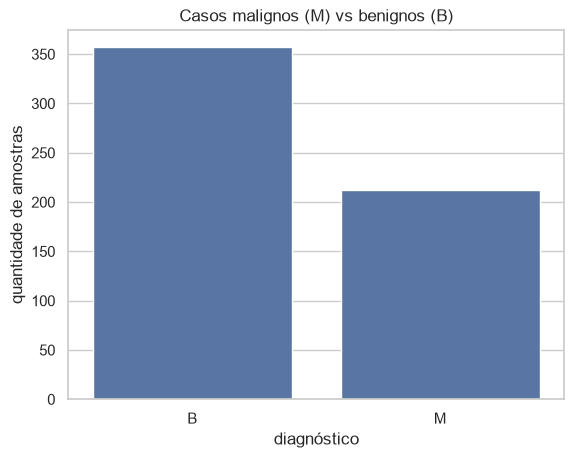

In [5]:
sns.countplot(data=dados, x=COLUNA_ALVO, order=["B", "M"])
plt.title("Casos malignos (M) vs benignos (B)")
plt.xlabel("diagnóstico")
plt.ylabel("quantidade de amostras")
plt.savefig(PASTA_FIGURAS / "01_distribuicao_diagnostico.png", dpi=150, bbox_inches="tight")
plt.show()

## Organização dos dados

In [6]:
# ============================================================
# Agrupamento de atributos
# Foram em: mean, se, worst
# ============================================================

atributos_principais = [c for c in dados.columns]

grupos_atributos = {
    "mean": {
        "atributos": [c for c in atributos_principais if c.endswith("_mean")],
        "titulo": "Distribuição — Média da característica [Mean]",
        "descricao": "Média da característica medida nas células/núcleo da amostra."
    },
    "se": {
        "atributos": [c for c in atributos_principais if c.endswith("_se")],
        "titulo": "Distribuição — Erro padrão (Standard Error) [SE]",
        "descricao": "Variabilidade/incerteza associada à estimativa da média."
    },
    "worst": {
        "atributos": [c for c in atributos_principais if c.endswith("_worst")],
        "titulo": "Distribuição — Pior/maior valor observado [Worst]",
        "descricao": "Valores associados aos núcleos considerados mais extremos dentro da amostra."
    }
}

## Histogramas dos atributos principais

Distribuição das seis primeiras features de média (`_mean`), que descrevem tamanho e forma do núcleo.

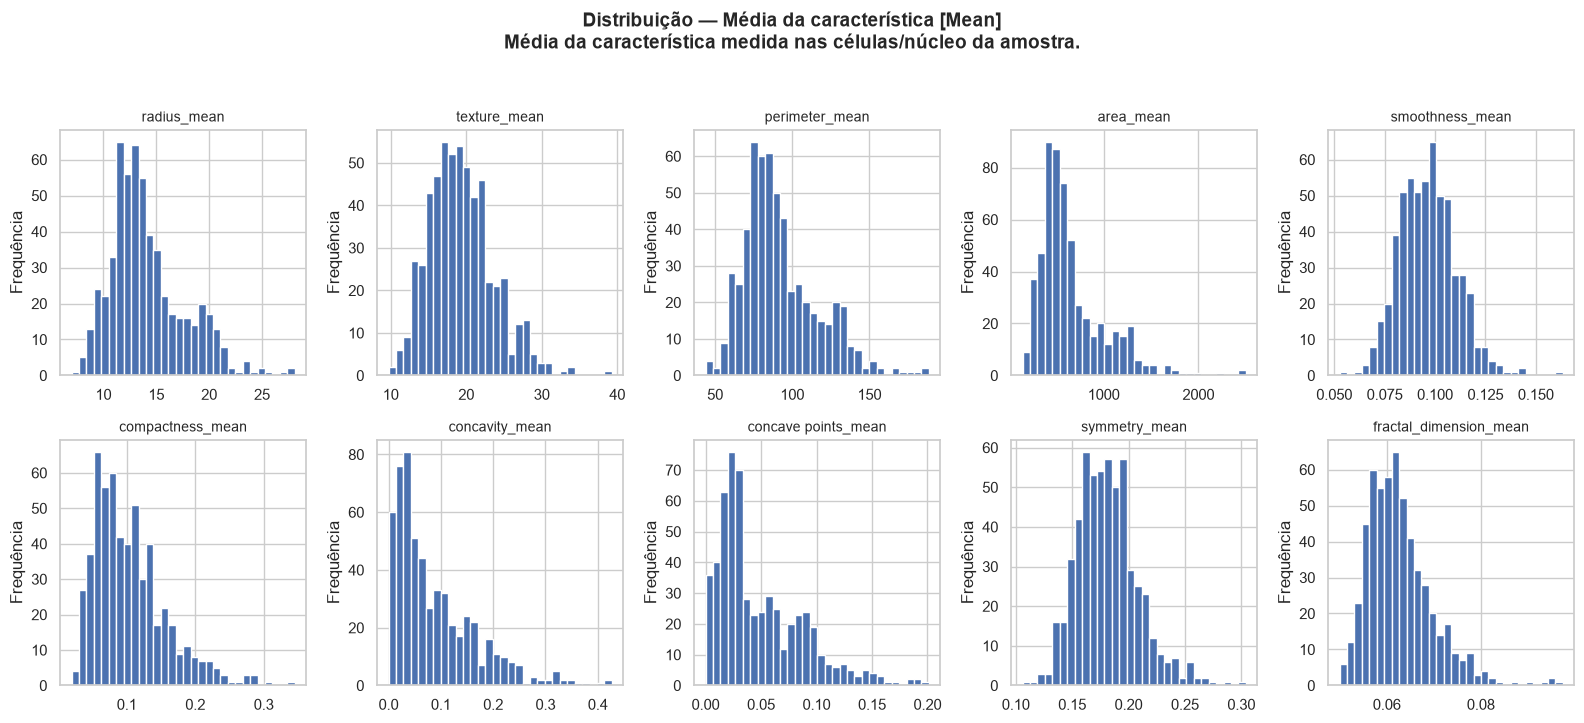

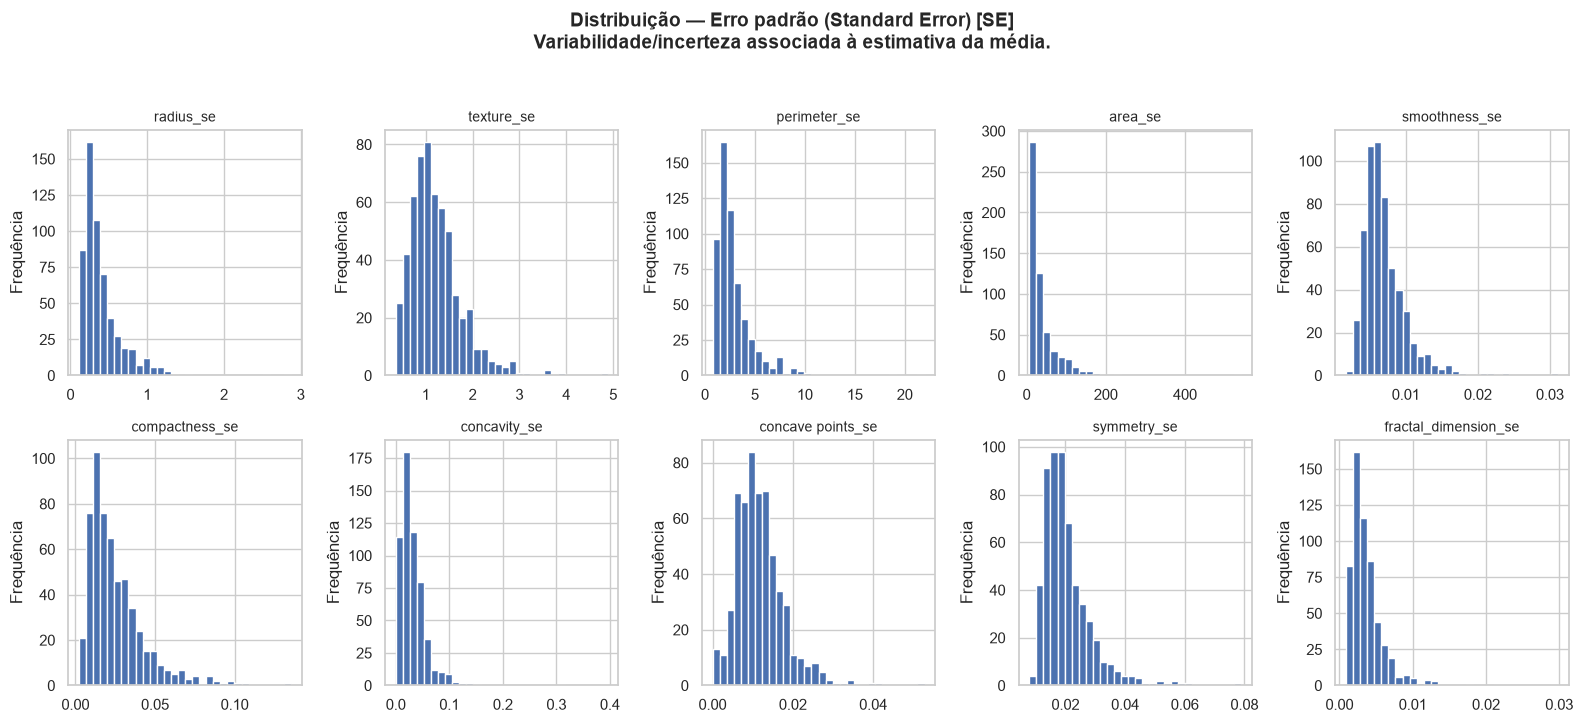

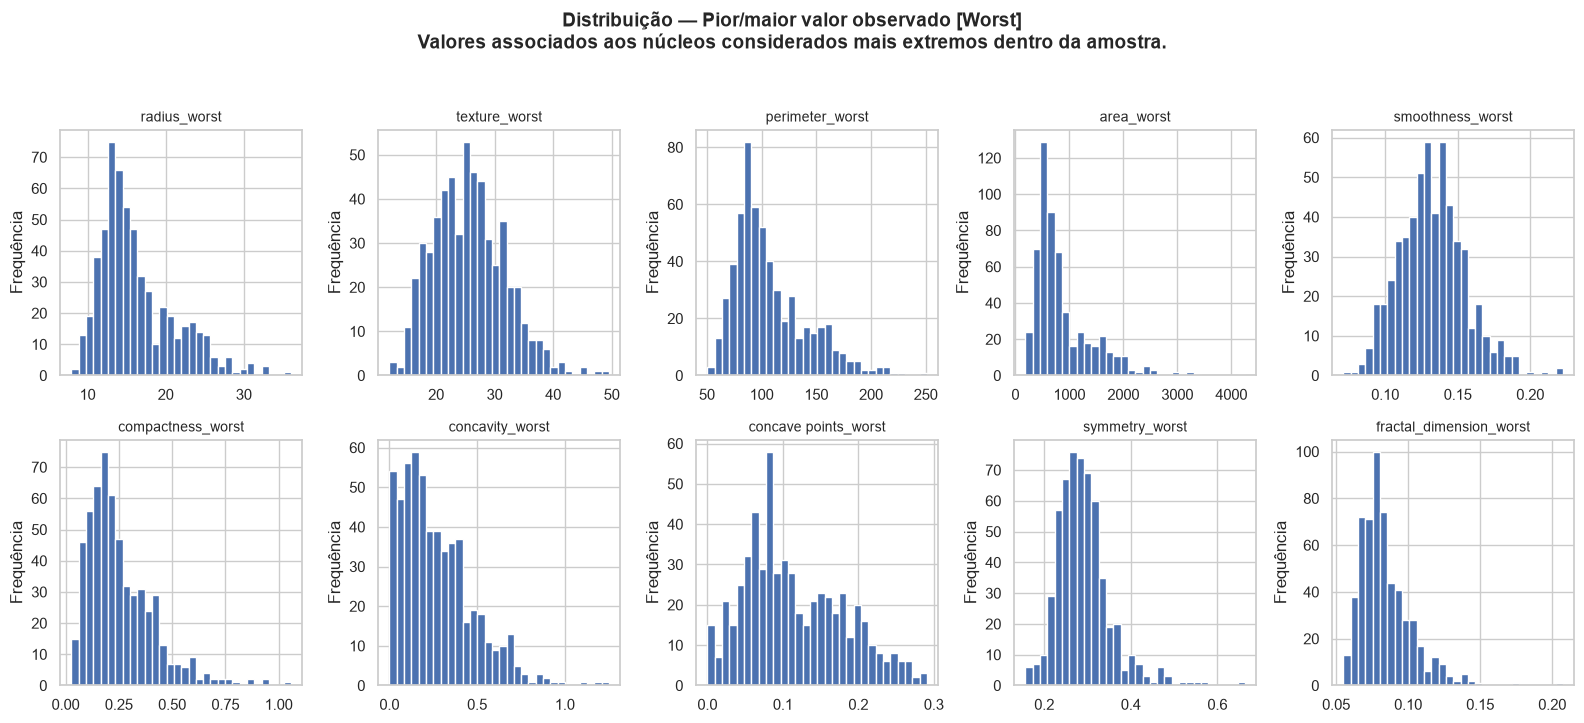

In [7]:
for grupo, info in grupos_atributos.items():

    fig, eixos = plt.subplots(2, 5, figsize=(16, 7))

    for eixo, atributo in zip(eixos.ravel(), info["atributos"]):

        eixo.hist(
            dados[atributo].dropna(),
            bins=30
        )

        eixo.set_title(atributo, fontsize=10)
        eixo.set_xlabel("")
        eixo.set_ylabel("Frequência")

    fig.suptitle(
        f'{info["titulo"]}\n{info["descricao"]}',
        fontsize=14,
        fontweight="bold",
        y=1.03
    )

    plt.tight_layout()

    plt.savefig(
        PASTA_FIGURAS / f"02_histogramas_{grupo}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Boxplots por diagnóstico

Comparamos tamanho e textura do núcleo entre benigno e maligno. Cada painel tem escala própria para `area_mean` não comprimir os demais.

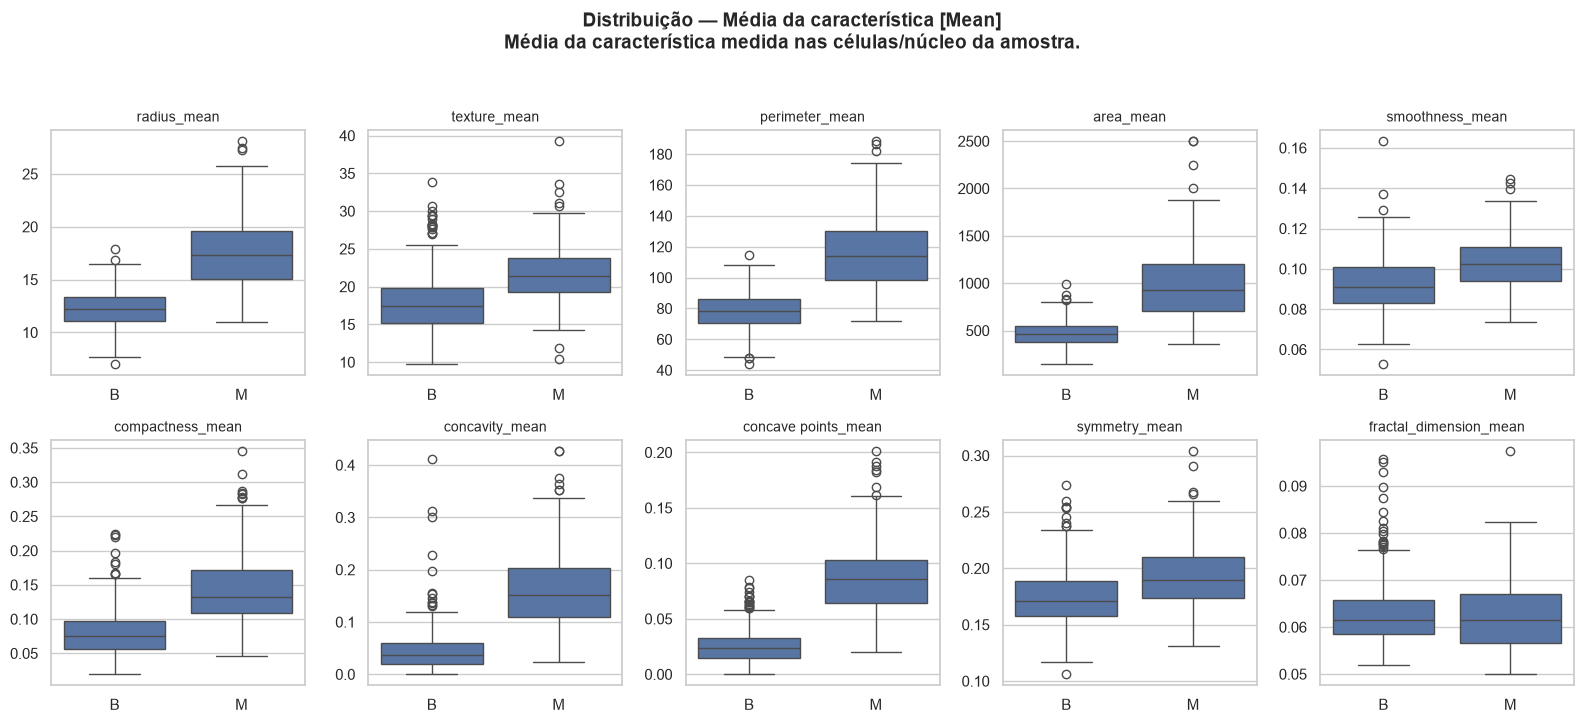

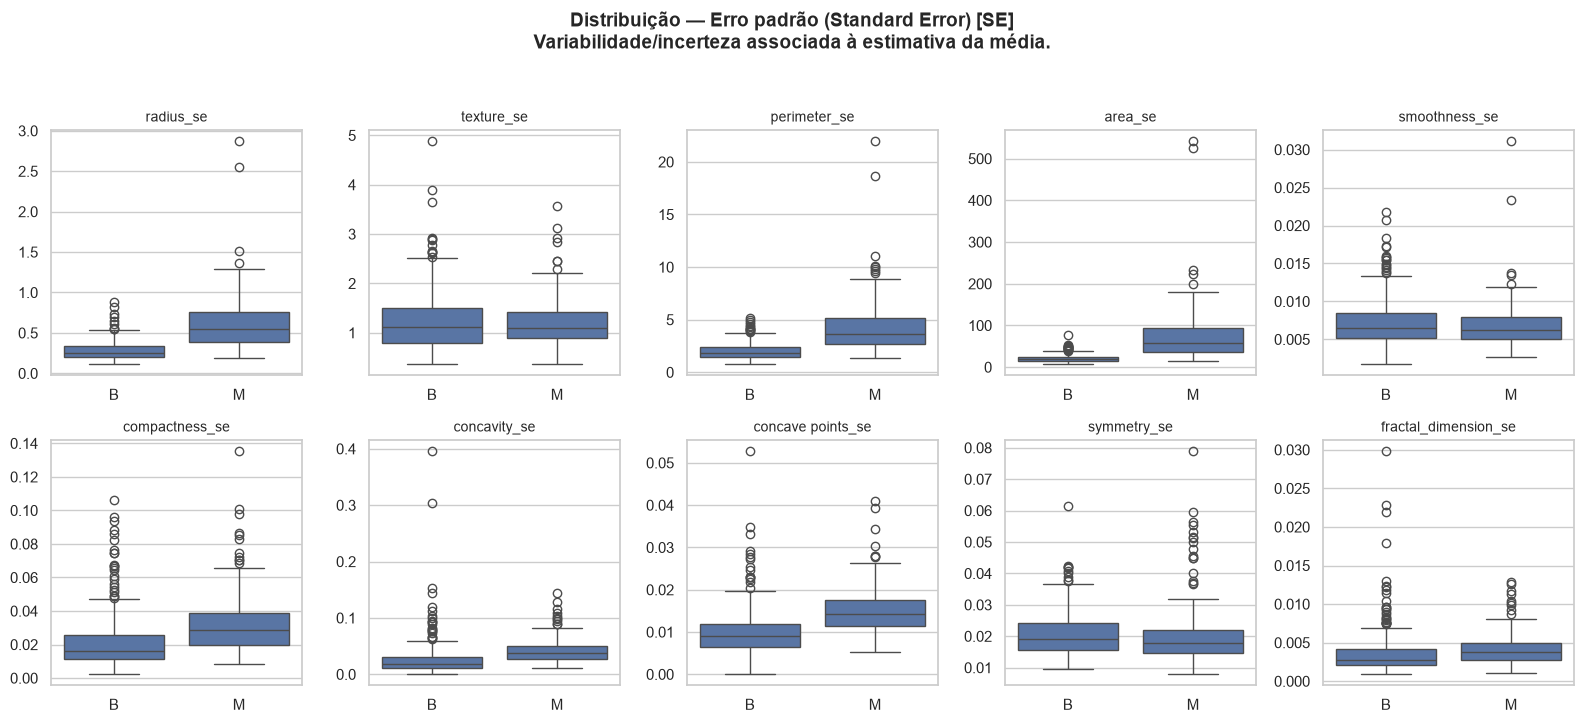

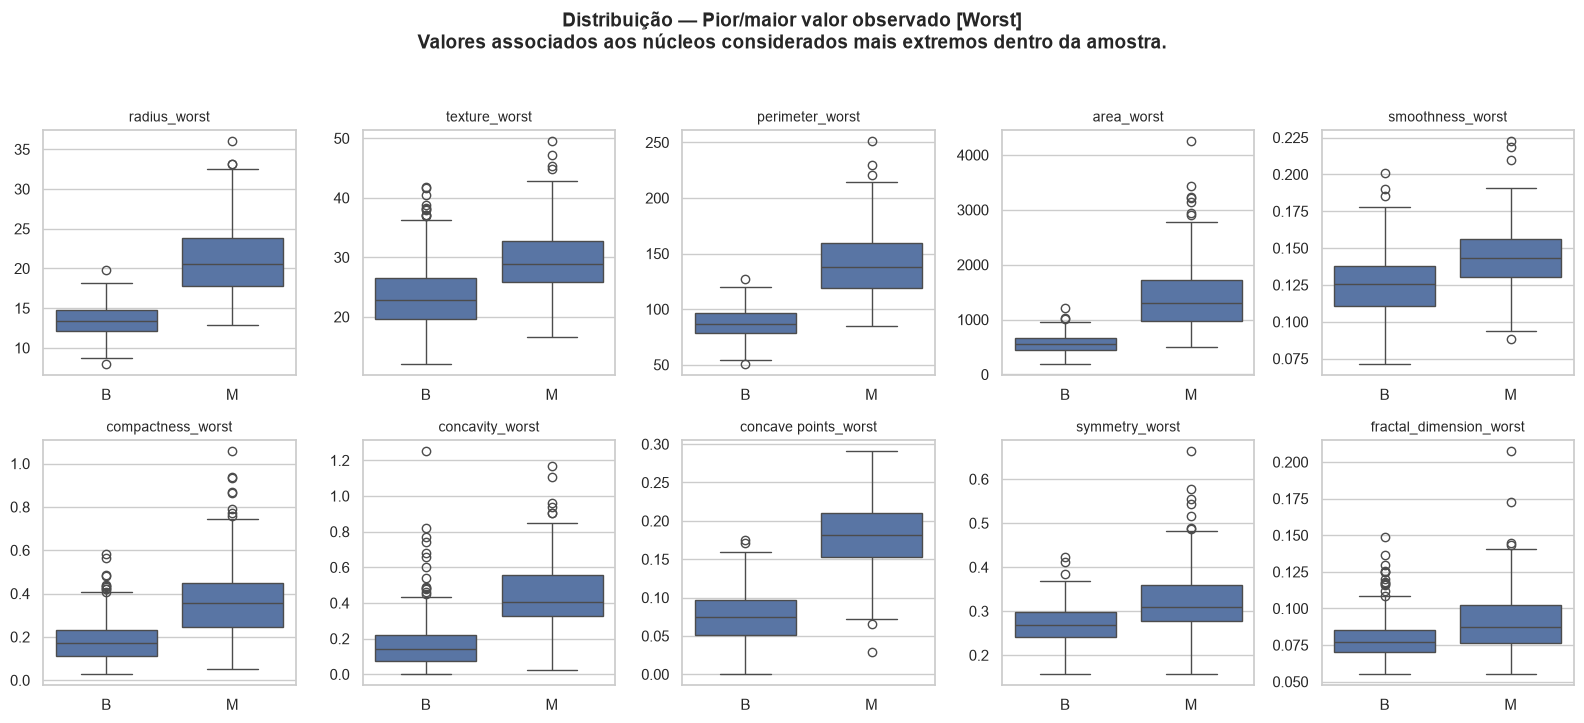

In [8]:
# ============================================================
# Boxplots por grupo de atributos
# ============================================================

for grupo, info in grupos_atributos.items():

    fig, eixos = plt.subplots(2, 5, figsize=(16, 7))

    for eixo, atributo in zip(eixos.ravel(), info["atributos"]):

        sns.boxplot(
            data=dados,
            x=COLUNA_ALVO,
            y=atributo,
            ax=eixo,
            order=["B", "M"]
        )

        eixo.set_title(atributo, fontsize=10)
        eixo.set_xlabel("")
        eixo.set_ylabel("")

    # Título do grupo + significado
    fig.suptitle(
        f'{info["titulo"]}\n{info["descricao"]}',
        fontsize=14,
        fontweight="bold",
        y=1.03
    )

    plt.tight_layout()

    plt.savefig(
        PASTA_FIGURAS / f"03_boxplot_{grupo}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Mapa de correlação

Correlação de Pearson entre atributos numéricos e o alvo recodificado (`maligno`: M = 1, B = 0). Serve só para exploração — essa recodificação ainda não entra no treino.

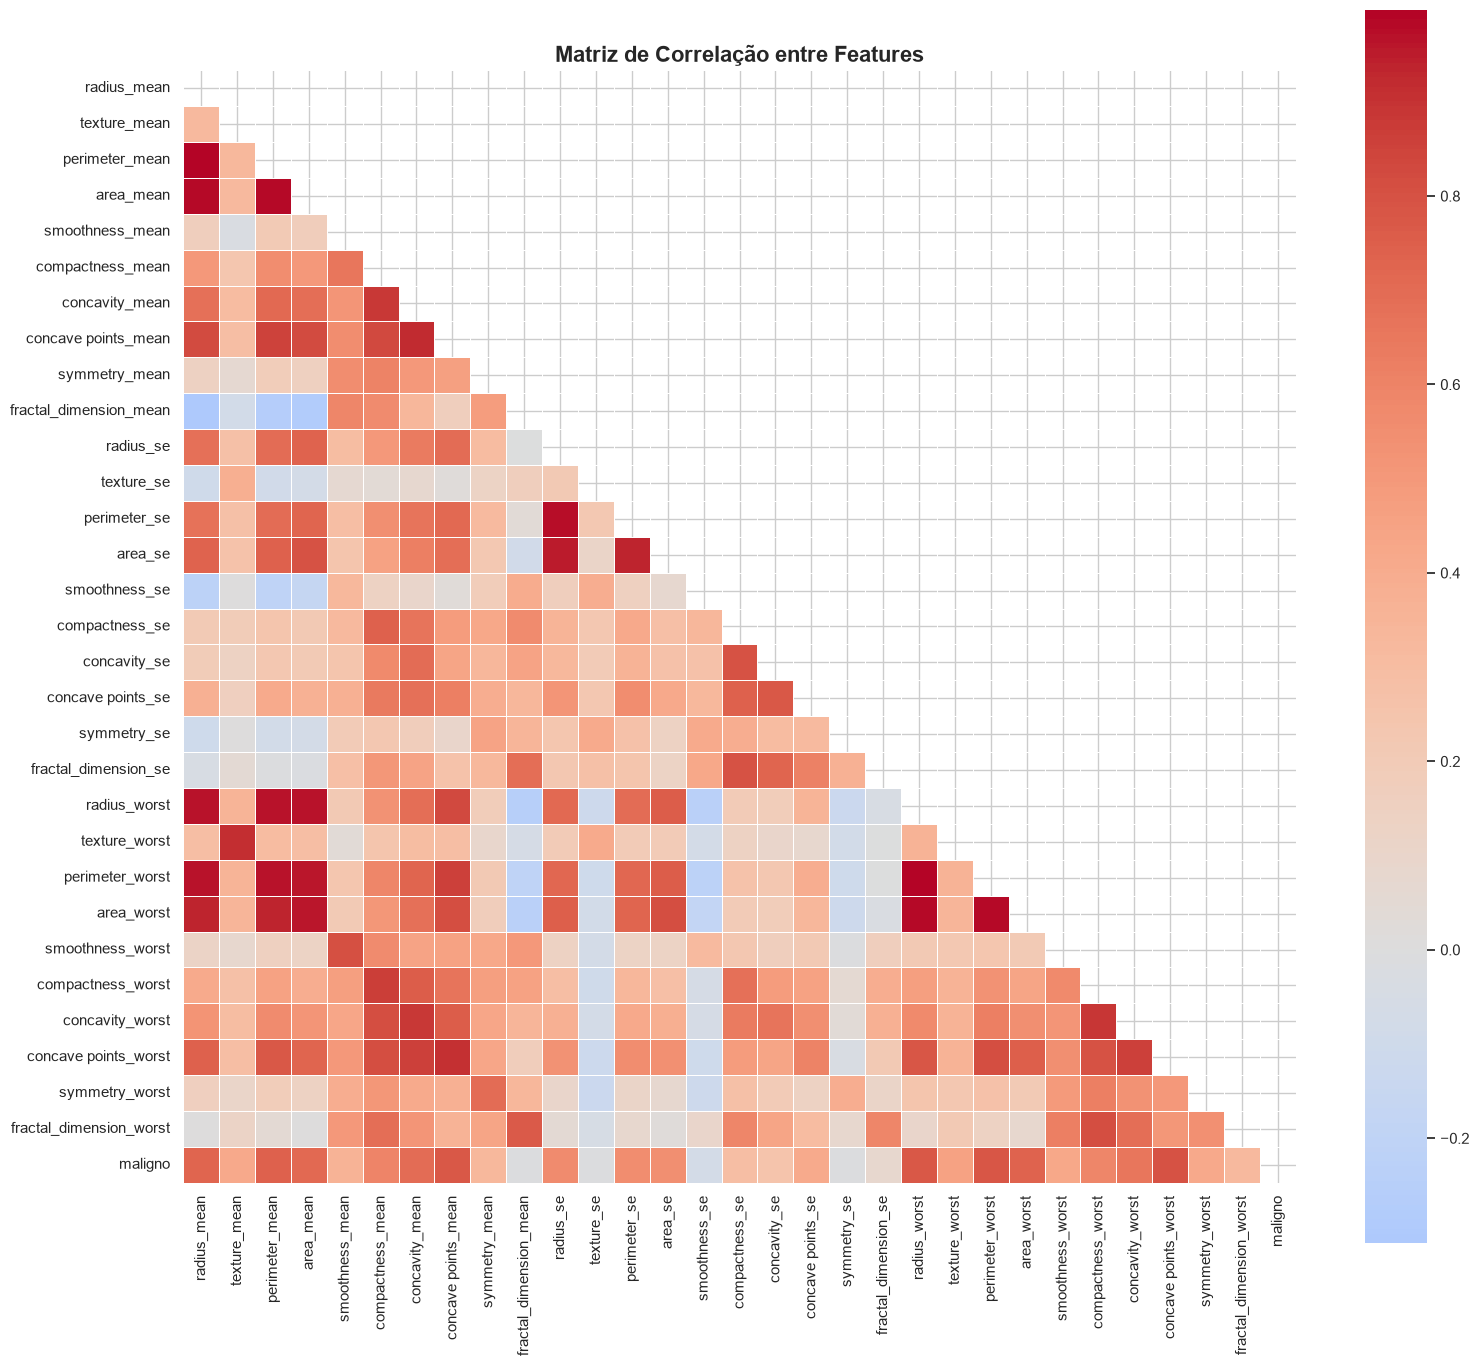

In [9]:
# Mapa de correlação — converte alvo para número só para correlacionar (EDA; não vai para o modelo ainda)
dados_corr = (
    dados.dropna(axis=1, how="all")
    .assign(maligno=dados[COLUNA_ALVO].map({"M": 1, "B": 0}))
)

plt.figure(figsize=(16, 14))
corr_matrix = dados_corr.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    linewidths=0.5,
)
plt.title("Matriz de Correlação entre Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "04_mapa_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()
